# 03 — UVI ฟ้าใส (Madronich) และผลของโอโซน

ใช้เฉพาะข้อมูลฝึก `train_merged.parquet` (ปทุมธานี 2023–2025 เฉพาะชั่วโมงกลางวัน) **ไม่ใช้ TEMIS/OMI**

สูตรใน rules: `UVI = 12.5 · μ^2.42 · (O3/300)^-1.23` โดย μ = cos(มุมเซนิท) และตัดค่าต่ำกว่า 0 ทิ้ง ฟังก์ชันอยู่ใน `src/physics.py`
`uvi_clear()` เป็นตัวหารของ target CMF_UVI (ตัดสินในวัน 2) จึงต้องรู้ว่าตัวเลือกเรื่องโอโซนและเรื่องเวลาในชั่วโมงเปลี่ยนค่า UVI ไปกี่ %

ในการคำนวณจะตัดชั่วโมงที่ UVI ฟ้าใส < 0.5 ออก เพื่อให้ตรงกับเกณฑ์ที่ใช้สร้าง CMF

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")


In [2]:
from src.metrics import error_metrics
from src.physics import load_ozone_climatology, local_month, ozone_climatology, uvi_clear_interval

df = pd.read_parquet(ROOT / "dataset" / "processed" / "train_merged.parquet")
t = df["time_utc"]
mid_local = (t - pd.Timedelta(minutes=30)).dt.tz_convert("Asia/Bangkok")
df["hour_local"] = mid_local.dt.hour + mid_local.dt.minute / 60
df["month"] = mid_local.dt.month

df["uvi_to3"] = uvi_clear_interval(t, ozone_du=df["nasa_ozone_du"].to_numpy())
df["uvi_clim"] = uvi_clear_interval(t)  # project default: monthly climatology, midpoint
df["uvi_300"] = uvi_clear_interval(t, ozone_du=300.0)
df["uvi_clim_mean"] = uvi_clear_interval(t, substeps=12)  # climatology, mean over the hour

use = df["uvi_to3"] >= 0.5
print(f"{len(df)} daytime hours, {use.sum()} with clear-sky UVI >= 0.5")
print("climatology (DU):", dict(zip(range(1, 13), load_ozone_climatology()[1:].round(1))))

13280 daytime hours, 10961 with clear-sky UVI >= 0.5
climatology (DU): {1: np.float64(243.2), 2: np.float64(245.9), 3: np.float64(256.0), 4: np.float64(272.5), 5: np.float64(278.1), 6: np.float64(274.5), 7: np.float64(270.5), 8: np.float64(269.5), 9: np.float64(268.4), 10: np.float64(264.4), 11: np.float64(253.7), 12: np.float64(244.7)}


## 1. โอโซน 3 แบบ: TO3 จริง vs climatology รายเดือน vs 300 DU
ความต่างคิดเป็น % ของ UVI ฟ้าใสเมื่อเทียบกับการใช้ TO3 จริง: `(UVI_แบบนั้น − UVI_TO3) / UVI_TO3 × 100`

In [3]:
rows = []
for name, col in [("Monthly climatology", "uvi_clim"), ("Constant 300 DU", "uvi_300")]:
    pct = (df.loc[use, col] - df.loc[use, "uvi_to3"]) / df.loc[use, "uvi_to3"] * 100
    rows.append({"ozone input": name, "mean %": pct.mean(), "mean |%|": pct.abs().mean(),
                 "p5 %": pct.quantile(0.05), "p95 %": pct.quantile(0.95), "max |%|": pct.abs().max(),
                 "MAE (UVI)": (df.loc[use, col] - df.loc[use, "uvi_to3"]).abs().mean()})
ozone_table = pd.DataFrame(rows).set_index("ozone input")
ozone_table.round(2)

,mean %,mean |%|,p5 %,p95 %,max |%|,MAE (UVI)
ozone input,,,,,,
Monthly climatology,-0.17,2.18,-4.80,4.23,12.25,0.15
Constant 300 DU,-15.23,15.23,-23.87,-8.11,29.78,1.04


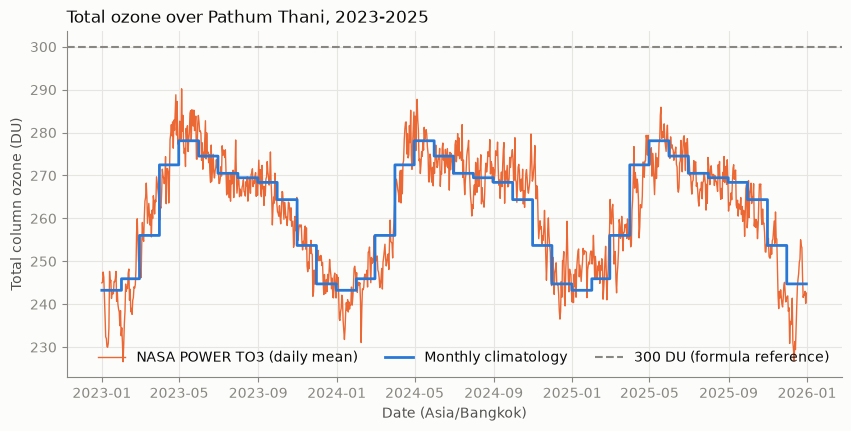

In [4]:
daily = df.set_index(mid_local.dt.tz_localize(None))["nasa_ozone_du"].resample("D").mean().dropna()
clim_line = ozone_climatology(daily.index.month.to_numpy())
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(daily.index, daily, color=C_NASA, lw=1, label="NASA POWER TO3 (daily mean)")
ax.plot(daily.index, clim_line, color=C_OM, lw=2, drawstyle="steps-mid", label="Monthly climatology")
ax.axhline(300, color=MUTED, lw=1.5, ls="--", label="300 DU (formula reference)")
ax.set_ylabel("Total column ozone (DU)")
ax.set_xlabel("Date (Asia/Bangkok)")
ax.set_title("Total ozone over Pathum Thani, 2023-2025", loc="left")
ax.legend(loc="lower right", ncols=3)
save(fig, "phys_ozone_climatology.png")

,climatology,300 DU
month,,
1,0.03,-22.72
2,0.10,-21.61
3,-0.07,-17.77
4,-0.33,-11.46
5,-0.39,-9.26
6,-0.16,-10.49
7,-0.06,-12.01
8,-0.19,-12.53
9,-0.28,-13.05


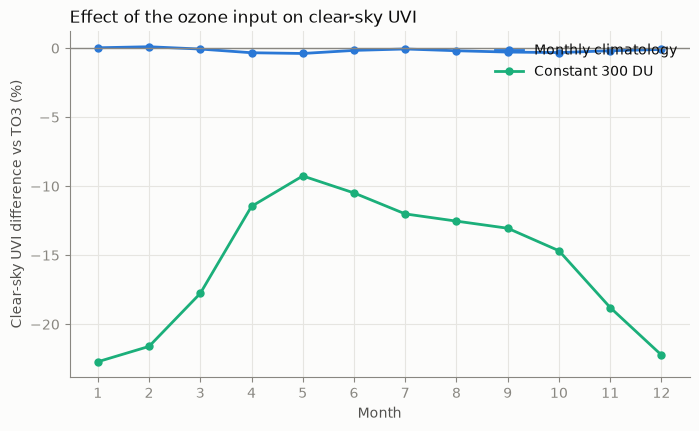

In [5]:
pct_clim = (df["uvi_clim"] - df["uvi_to3"]) / df["uvi_to3"] * 100
pct_300 = (df["uvi_300"] - df["uvi_to3"]) / df["uvi_to3"] * 100
by_month = pd.DataFrame({"climatology": pct_clim[use], "300 DU": pct_300[use],
                         "month": df.loc[use, "month"]}).groupby("month").mean()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(by_month.index, by_month["climatology"], color=C_OM, marker="o", ms=5, label="Monthly climatology")
ax.plot(by_month.index, by_month["300 DU"], color=C_THIRD, marker="o", ms=5, label="Constant 300 DU")
ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Clear-sky UVI difference vs TO3 (%)")
ax.set_title("Effect of the ozone input on clear-sky UVI", loc="left")
ax.legend(loc="upper right")
save(fig, "phys_ozone_effect.png")
by_month.round(2)

### ทำไมใช้ climatology รายเดือนเป็นค่าเริ่มต้น (train–serve consistency)
- **ตอนใช้งานจริงไม่มี TO3 แบบ real-time:** NASA POWER ช้ากว่าปัจจุบันหลายเดือน และแอปไม่ควรต้องเรียก NASA POWER ส่วน climatology เป็นไฟล์เล็ก ๆ (`source_code/models/ozone_climatology_v1.json`) ที่แอปและ API อ่านได้เอง
- **ตัวหารของ CMF ต้องคำนวณแบบเดียวกันทั้งตอนฝึกและตอนใช้งาน:** ถ้าตอนฝึกใช้ TO3 จริงแต่ตอนใช้งานใช้ค่าอื่น โมเดลจะเรียนรู้ CMF ที่อ้างอิงกับ clear-sky คนละแบบกับที่ใช้คูณกลับตอนทำนาย ทำให้ UVI ที่ทำนายได้มี bias เป็นระบบ ขนาดเท่ากับความต่างในตารางด้านบน ถ้าใช้ climatology ทั้งสองฝั่ง ส่วนที่ climatology คลาดจากโอโซนจริงรายวันจะถูกดูดซับเข้าไปใน CMF ที่โมเดลเรียนรู้ ตัว UVI ที่ทำนาย (= clear-sky × CMF) จึงยังสอดคล้องกัน
- **300 DU ไม่เหมาะกับเขตร้อน:** โอโซนที่ปทุมธานีอยู่ราว 243–278 DU จึงต่ำกว่า 300 ตลอดปี ถ้าใช้ 300 DU UVI ฟ้าใสจะต่ำลงอย่างเป็นระบบ (ดูตาราง)
- **ข้อควรระวัง:** climatology สร้างจาก TO3 ปี 2023–2025 ซึ่งครอบคลุมช่วง validation ของการแบ่งตามเวลาในวันถัด ๆ ไปด้วย แต่เป็นค่าเฉลี่ยรายเดือนของ input ทางกายภาพ (ไม่ใช่ target) และความแปรปรวนระหว่างปีต่ำ (SD รายเดือน 4–8 DU) ความเสี่ยง leakage จึงน้อย จะระบุไว้ในรายงาน

## 2. จุดกึ่งกลางชั่วโมง vs ค่าเฉลี่ยทั้งชั่วโมง
NASA POWER รายงานค่าเฉลี่ยรายชั่วโมง แต่ rules ตอนนี้ให้คำนวณตัวหารที่จุดกึ่งกลางชั่วโมง เนื่องจาก μ^2.42 ไม่เป็นเส้นตรง สองแบบนี้จึงต่างกันมากที่สุดตอนเช้าและเย็น

overall mean |%|: 1.72


midpoint vs hourly mean (%)             
                            mean    min   max
hour                                         
7.5                        -6.38 -13.03 -4.21
8.5                        -1.71  -3.29 -0.98
9.5                        -0.12  -0.48  0.05
10.5                        0.43   0.34  0.54
11.5                        0.64   0.58  0.73
12.5                        0.69   0.62  0.77
13.5                        0.58   0.53  0.67
14.5                        0.26   0.08  0.38
15.5                       -0.57  -1.30 -0.23
16.5                       -3.37  -7.13 -1.66
17.5                       -9.78 -13.28 -7.19

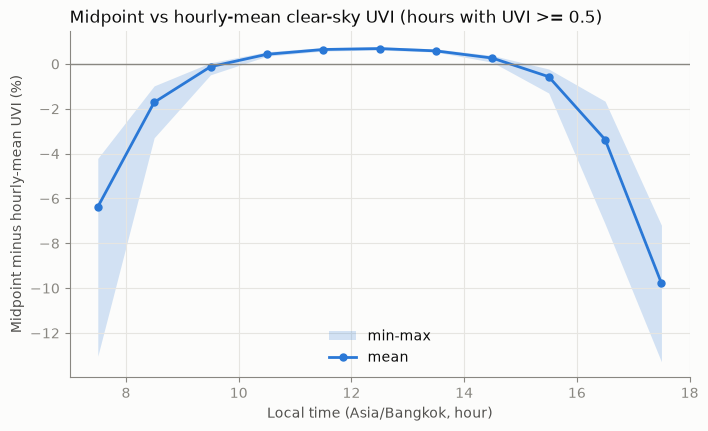

In [6]:
pct_mid = (df["uvi_clim"] - df["uvi_clim_mean"]) / df["uvi_clim_mean"] * 100
use_mean = df["uvi_clim_mean"] >= 0.5
by_hour = pd.DataFrame({"midpoint vs hourly mean (%)": pct_mid[use_mean],
                        "hour": df.loc[use_mean, "hour_local"]}).groupby("hour").agg(["mean", "min", "max"])
fig, ax = plt.subplots(figsize=(8, 4.5))
h = by_hour.index
ax.fill_between(h, by_hour.iloc[:, 1], by_hour.iloc[:, 2], color=C_OM, alpha=0.2, lw=0, label="min-max")
ax.plot(h, by_hour.iloc[:, 0], color=C_OM, marker="o", ms=5, label="mean")
ax.axhline(0, color=MUTED, lw=1)
ax.set_xlabel("Local time (Asia/Bangkok, hour)")
ax.set_ylabel("Midpoint minus hourly-mean UVI (%)")
ax.set_title("Midpoint vs hourly-mean clear-sky UVI (hours with UVI >= 0.5)", loc="left")
ax.legend(loc="lower center")
save(fig, "phys_midpoint_vs_mean.png")
print(f"overall mean |%|: {pct_mid[use_mean].abs().mean():.2f}")
by_hour.round(2)

## 3. เทียบกับ Open-Meteo `uv_index_clear_sky` (ทุกชั่วโมงกลางวัน)
ในตารางข้อ 3–4 `bias` = แหล่งข้อมูล (Open-Meteo / NASA POWER) − Madronich

In [7]:
comp = []
for name, col in [("uvi_clear (clim, midpoint)", "uvi_clim"), ("uvi_clear (clim, hourly mean)", "uvi_clim_mean")]:
    comp.append({"model": name, "reference": "Open-Meteo uv_index_clear_sky", "subset": "daytime",
                 **error_metrics(df.loc[use, "uv_index_clear_sky"], df.loc[use, col])})
pd.DataFrame(comp).round(3)

,model,reference,subset,n,mae,bias,rmse,r
0,"uvi_clear (clim, midpoint)",Open-Meteo uv_index_clear_sky,daytime,10961,1.782,-1.452,2.336,0.992
1,"uvi_clear (clim, hourly mean)",Open-Meteo uv_index_clear_sky,daytime,10961,1.738,-1.443,2.290,0.992


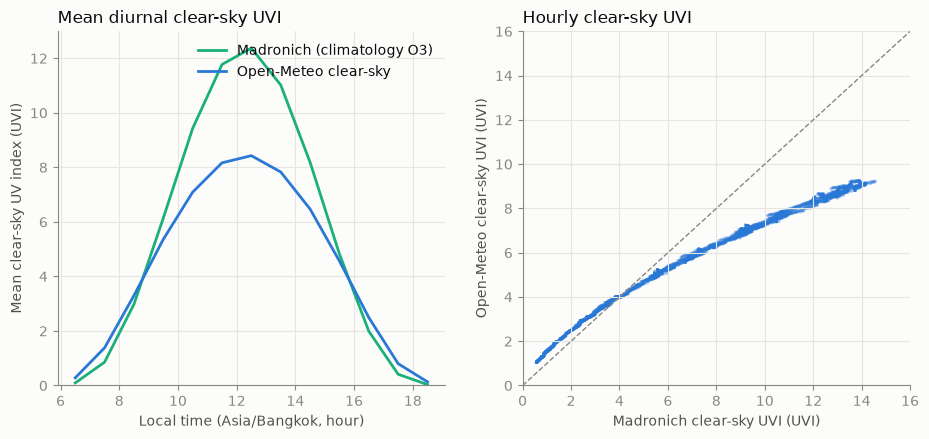

In [8]:
hourly = df.groupby("hour_local")[["uvi_clim_mean", "uv_index_clear_sky"]].mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
ax.plot(hourly.index, hourly["uvi_clim_mean"], color=C_THIRD, label="Madronich (climatology O3)")
ax.plot(hourly.index, hourly["uv_index_clear_sky"], color=C_OM, label="Open-Meteo clear-sky")
ax.set_xlabel("Local time (Asia/Bangkok, hour)"); ax.set_ylabel("Mean clear-sky UV index (UVI)")
ax.set_title("Mean diurnal clear-sky UVI", loc="left"); ax.set_ylim(0, None); ax.legend(loc="upper right")
ax = axes[1]
ax.scatter(df.loc[use, "uvi_clim_mean"], df.loc[use, "uv_index_clear_sky"], s=4, color=C_OM, alpha=0.25, lw=0)
ax.plot([0, 16], [0, 16], color=MUTED, lw=1, ls="--")
ax.set_xlim(0, 16); ax.set_ylim(0, 16)
ax.set_xlabel("Madronich clear-sky UVI (UVI)"); ax.set_ylabel("Open-Meteo clear-sky UVI (UVI)")
ax.set_title("Hourly clear-sky UVI", loc="left")
save(fig, "phys_vs_openmeteo.png")

## 4. เทียบกับ NASA POWER `nasa_uvi` เฉพาะชั่วโมงที่ฟ้าเปิด
เกณฑ์ชั่วโมงฟ้าเปิด: `nasa_cloud_pct < 10` **และ** clear-sky index `nasa_sw_all_wm2 / nasa_sw_clear_wm2 > 0.9`
ค่าของ NASA POWER เป็นค่าเฉลี่ยรายชั่วโมง จึงควรเทียบกับแบบ hourly mean

In [9]:
kt = df["nasa_sw_all_wm2"] / df["nasa_sw_clear_wm2"].where(df["nasa_sw_clear_wm2"] > 50)
clear = use & (df["nasa_cloud_pct"] < 10) & (kt > 0.9)
print("clear-sky hours:", int(clear.sum()))
comp = []
for name, col in [("uvi_clear (TO3, midpoint)", "uvi_to3"), ("uvi_clear (clim, midpoint)", "uvi_clim"),
                  ("uvi_clear (clim, hourly mean)", "uvi_clim_mean"), ("uvi_clear (300 DU, midpoint)", "uvi_300")]:
    comp.append({"model": name, "reference": "NASA POWER nasa_uvi", "subset": "clear hours",
                 **error_metrics(df.loc[clear, "nasa_uvi"], df.loc[clear, col])})
nasa_table = pd.DataFrame(comp)
nasa_table["ratio NASA/model"] = [
    (df.loc[clear, "nasa_uvi"] / df.loc[clear, c]).median()
    for c in ["uvi_to3", "uvi_clim", "uvi_clim_mean", "uvi_300"]]
nasa_table.round(3)

clear-sky hours: 1659


,model,reference,subset,n,mae,bias,rmse,r,ratio NASA/model
0,"uvi_clear (TO3, midpoint)",NASA POWER nasa_uvi,clear hours,1659,1.881,-1.881,2.203,0.973,0.727
1,"uvi_clear (clim, midpoint)",NASA POWER nasa_uvi,clear hours,1659,1.924,-1.924,2.264,0.971,0.723
2,"uvi_clear (clim, hourly mean)",NASA POWER nasa_uvi,clear hours,1659,1.906,-1.906,2.232,0.970,0.722
3,"uvi_clear (300 DU, midpoint)",NASA POWER nasa_uvi,clear hours,1659,0.851,-0.638,1.174,0.955,0.878


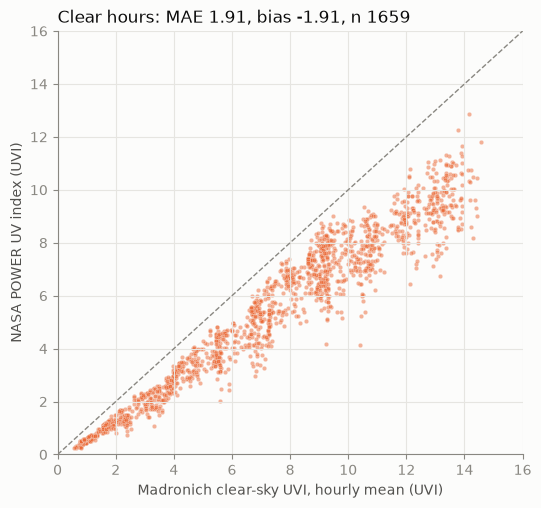

In [10]:
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(df.loc[clear, "uvi_clim_mean"], df.loc[clear, "nasa_uvi"], s=10, color=C_NASA, alpha=0.5,
           edgecolors="#fcfcfb", linewidths=0.3)
ax.plot([0, 16], [0, 16], color=MUTED, lw=1, ls="--")
ax.set_xlim(0, 16); ax.set_ylim(0, 16)
m = error_metrics(df.loc[clear, "nasa_uvi"], df.loc[clear, "uvi_clim_mean"])
ax.set_xlabel("Madronich clear-sky UVI, hourly mean (UVI)")
ax.set_ylabel("NASA POWER UV index (UVI)")
ax.set_title(f"Clear hours: MAE {m['mae']:.2f}, bias {m['bias']:+.2f}, n {m['n']}", loc="left")
save(fig, "phys_vs_nasa_clear.png")

## 5. ทำไม NASA POWER ต่ำกว่า Madronich ในชั่วโมงฟ้าเปิด: ผลของฝุ่นละออง (AOD)
สูตร Madronich ไม่มีเทอมของ aerosol ส่วนปทุมธานีมี AOD เฉลี่ยราว 0.46 ซึ่งถือว่าสูง ถ้าส่วนต่างเกิดจากฝุ่นละอองจริง อัตราส่วน NASA/Madronich ควรลดลงเมื่อ AOD เพิ่มขึ้น

corr(ratio, AOD) = -0.468


,median,n
AOD quartile,,
"(0.059, 0.24]",0.802,419
"(0.24, 0.39]",0.750,417
"(0.39, 0.57]",0.701,423
"(0.57, 1.62]",0.658,400


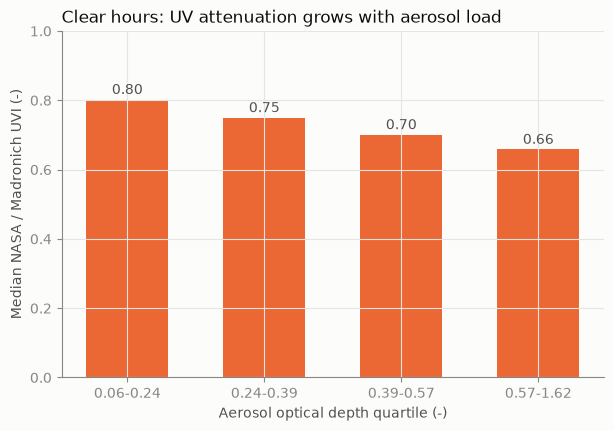

In [11]:
c = df[clear].copy()
c["ratio"] = c["nasa_uvi"] / c["uvi_clim_mean"]
c["AOD quartile"] = pd.qcut(c["aerosol_optical_depth"], 4)
aod_table = c.groupby("AOD quartile", observed=True)["ratio"].agg(median="median", n="count")
print("corr(ratio, AOD) =", round(c["ratio"].corr(c["aerosol_optical_depth"]), 3))

fig, ax = plt.subplots(figsize=(7, 4.5))
labels = [f"{iv.left:.2f}-{iv.right:.2f}" for iv in aod_table.index]
ax.bar(range(len(labels)), aod_table["median"], color=C_NASA, width=0.6)
ax.set_xticks(range(len(labels)), labels)
for i, v in enumerate(aod_table["median"]):
    ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, 4), ha="center", color=INK2)
ax.set_ylim(0, 1)
ax.set_xlabel("Aerosol optical depth quartile (-)")
ax.set_ylabel("Median NASA / Madronich UVI (-)")
ax.set_title("Clear hours: UV attenuation grows with aerosol load", loc="left")
save(fig, "phys_aod_ratio.png")
aod_table.round(3)

## สรุปผล

In [12]:
print("Ozone input vs TO3 (hours with clear-sky UVI >= 0.5):")
print(ozone_table[["mean %", "mean |%|", "p95 %", "max |%|"]].round(2).to_string())
print(f"\nMidpoint vs hourly mean: mean |%| = {pct_mid[use_mean].abs().mean():.2f}")
print("\nvs NASA POWER on clear hours:")
print(nasa_table[["model", "n", "mae", "bias", "r", "ratio NASA/model"]].round(3).to_string(index=False))

Ozone input vs TO3 (hours with clear-sky UVI >= 0.5):
                     mean %  mean |%|  p95 %  max |%|
ozone input                                          
Monthly climatology   -0.17      2.18   4.23    12.25
Constant 300 DU      -15.23     15.23  -8.11    29.78

Midpoint vs hourly mean: mean |%| = 1.72

vs NASA POWER on clear hours:
                        model    n   mae   bias     r  ratio NASA/model
    uvi_clear (TO3, midpoint) 1659 1.881 -1.881 0.973             0.727
   uvi_clear (clim, midpoint) 1659 1.924 -1.924 0.971             0.723
uvi_clear (clim, hourly mean) 1659 1.906 -1.906 0.970             0.722
 uvi_clear (300 DU, midpoint) 1659 0.851 -0.638 0.955             0.878


### ข้อสรุป (ตัวเลขดูได้จากเซลล์ด้านบน)
1. **เรื่องโอโซน:** climatology รายเดือนต่างจาก TO3 จริงเฉลี่ยราว 2% ของ UVI (p95 ~4%) ส่วนค่าคงที่ 300 DU ทำให้ UVI ต่ำเป็นระบบราว 15% (ถึง ~23% ในเดือนหนาว) จึงใช้ **climatology เป็นค่าเริ่มต้นทั้งตอนฝึกและตอนใช้งาน**
2. **จุดกึ่งกลางชั่วโมง vs ค่าเฉลี่ยทั้งชั่วโมง:** ช่วงกลางวันต่างกันไม่ถึง 1% แต่ชั่วโมงแรกและชั่วโมงสุดท้ายของวันต่างกัน 6–10% (สูงสุด ~13%) ค่าของ NASA POWER เป็นค่าเฉลี่ยรายชั่วโมง **ตัดสินแล้ว: ตัวหารของ CMF ใช้ค่าเฉลี่ยทั้งชั่วโมง** (`uvi_clear_interval(..., substeps=CMF_SUBSTEPS)` = 12) และแก้ rules แล้ว
3. **Open-Meteo clear-sky** ต่ำกว่า Madronich ราว 1.4 UVI แต่ r = 0.99 คือรูปร่างตรงกันแต่ระดับต่ำกว่า สอดคล้องกับผลวัน 2 ที่ Open-Meteo ต่ำกว่า TEMIS
4. **NASA POWER ในชั่วโมงฟ้าเปิด** ได้ประมาณ 0.72 เท่าของ Madronich และอัตราส่วนนี้ลดลงเมื่อ AOD เพิ่ม (0.80 → 0.66) แปลว่า **CMF_UVI = NASA/Madronich จะรวมผลของฝุ่นละอองเข้าไปด้วย ไม่ได้มีแค่ผลของเมฆ** แม้ฟ้าจะเปิด CMF ก็อยู่ราว 0.7–0.8 ไม่ใช่ 1 ดังนั้นโมเดลวัน 5 ขึ้นไปต้องมี AOD / PM2.5 เป็น feature ส่วนผลที่ 300 DU ดู "ใกล้" NASA กว่านั้นเป็นความบังเอิญ เพราะความผิดพลาดสองอย่างหักล้างกัน จึงไม่ใช่เหตุผลให้เลือกใช้ 300 DU